Data Import And Check


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
products = pd.read_csv("products.csv")
sellers = pd.read_csv("sellers.csv")
payments = pd.read_csv("payments.csv")

In [ ]:
print(customers.head())
print(orders.head())
print(order_items.head())
print(products.head())

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cd

In [ ]:
# Convert date column
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

# Merge all datasets into one master dataframe
df = order_items.merge(orders, on='order_id') \
                .merge(customers, on='customer_id') \
                .merge(products, on='product_id') \
                .merge(sellers, on='seller_id')

Basics Analysis


Top 10 Cities:
 customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64


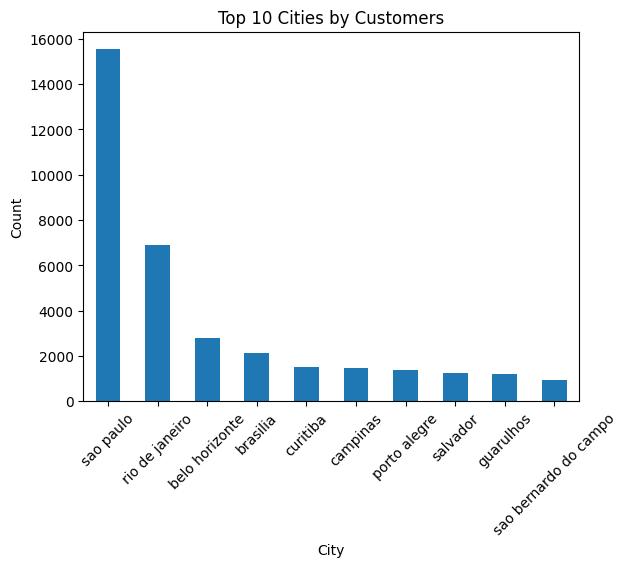

In [ ]:
#1 all unique cities
city_counts = customers['customer_city'].value_counts()
print("\nTop 10 Cities:\n", city_counts.head(10))

# PLOT
plt.figure()
city_counts.head(10).plot(kind='bar')
plt.title("Top 10 Cities by Customers")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Total Orders in 2017: 45101


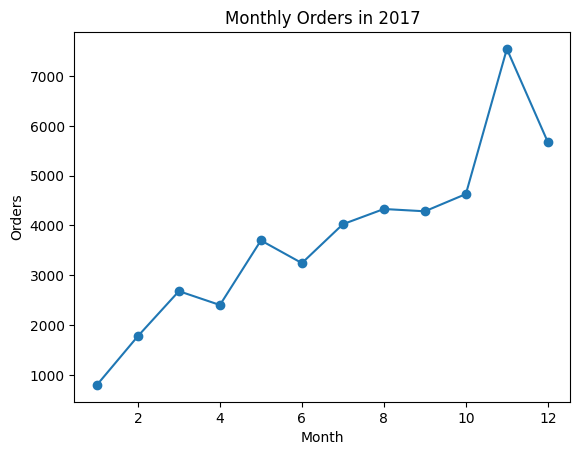

In [ ]:
#2No. of orders in 2017


orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders_2017 = orders[orders['order_purchase_timestamp'].dt.year == 2017]

monthly_orders_2017 = orders_2017.groupby(
    orders_2017['order_purchase_timestamp'].dt.month
).size()
print("Total Orders in 2017:", len(orders_2017))
plt.figure()
monthly_orders_2017.plot(marker='o')
plt.title("Monthly Orders in 2017")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()

product category
HEALTH BEAUTY                  1258681.34
Watches present                1205005.68
bed table bath                 1036988.68
sport leisure                   988048.97
computer accessories            911954.32
                                  ...    
flowers                           1110.04
House Comfort 2                    760.27
cds music dvds                     730.00
Fashion Children's Clothing        569.85
insurance and services             283.29
Name: price, Length: 73, dtype: float64


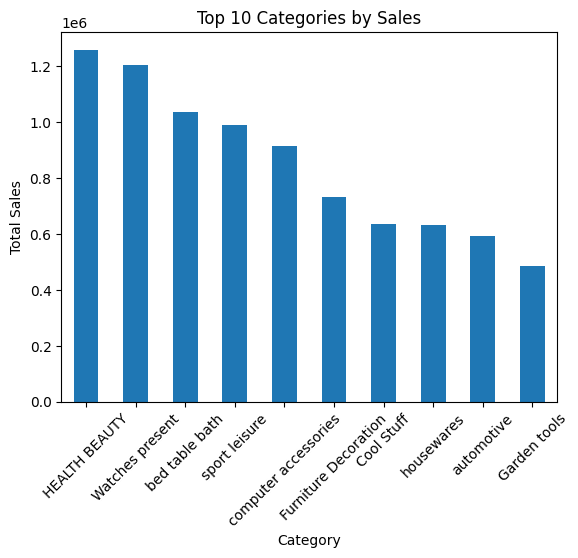

In [ ]:
#3 Total Sales Per Cateogry


sales_data = order_items.merge(products, on='product_id')

sales_per_category = sales_data.groupby('product category')['price'].sum()

top_categories = sales_per_category.sort_values(ascending=False).head(10)
print(sales_per_category.sort_values(ascending=False))

plt.figure()
top_categories.plot(kind='bar')
plt.title("Top 10 Categories by Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

Percentage: product category
Agro Industria e Comercio    0.540784
Art                          0.180454
Arts and Crafts              0.013525
Bags Accessories             1.047039
Blu Ray DVDs                 0.044731
                               ...   
sport leisure                7.366843
stationary store             1.721901
technical books              0.142379
telephony                    2.413249
toys                         3.608281
Name: price, Length: 73, dtype: float64


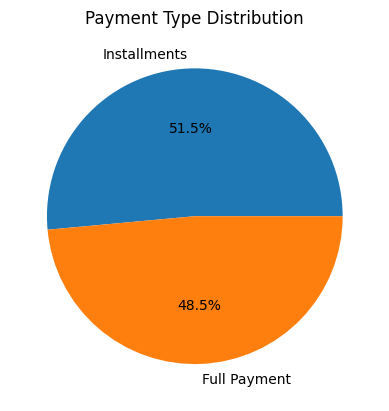

In [ ]:
#4 orders paid in installments

installment_orders = payments[payments['payment_installments'] > 1]['order_id'].nunique()
total_orders = payments['order_id'].nunique()
print("Percentage:", percentage)
labels = ['Installments', 'Full Payment']
values = [installment_orders, total_orders - installment_orders]

plt.figure()
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Payment Type Distribution")
plt.show()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: customer_id, dtype: int64


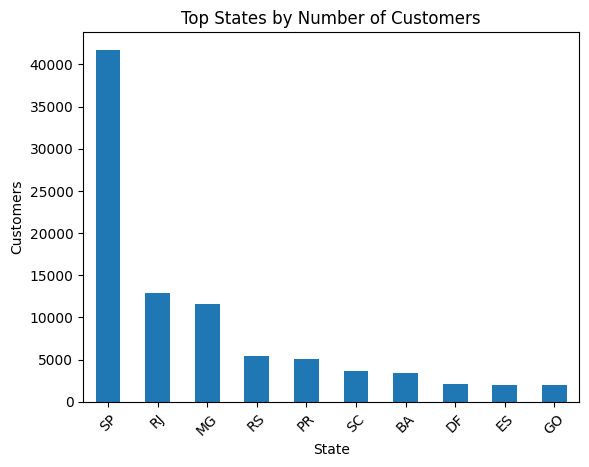

In [ ]:
#5 Customer per state

customers_per_state = customers.groupby('customer_state')['customer_id'].count()
print(customers_per_state.sort_values(ascending=False))
top_states = customers_per_state.sort_values(ascending=False).head(10)

plt.figure()
top_states.plot(kind='bar')
plt.title("Top States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.show()

Intermediate

order_purchase_timestamp
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64


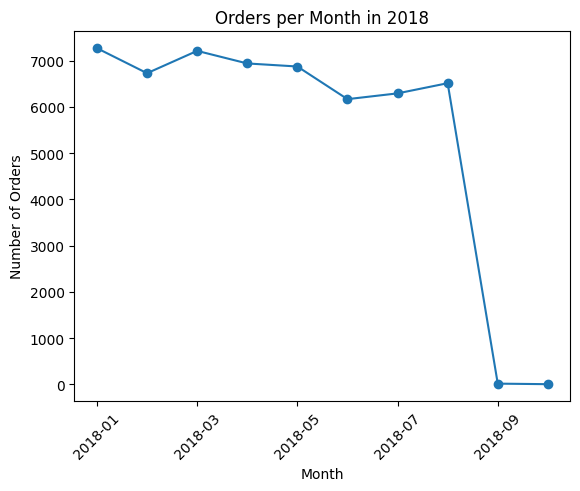

In [ ]:
#1 Orders Per Month
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders_2018 = orders[orders['order_purchase_timestamp'].dt.year == 2018]

monthly_orders = orders_2018.groupby(
    orders_2018['order_purchase_timestamp'].dt.to_period('M')
).size()
monthly_orders.index = monthly_orders.index.astype(str)
print(orders_per_month)

plt.figure()
monthly_orders.plot(marker='o')
plt.title("Orders per Month in 2018")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

customer_city
padre carvalho    7.0
celso ramos       6.5
datas             6.0
candido godoi     6.0
matias olimpio    5.0
Name: num_products, dtype: float64


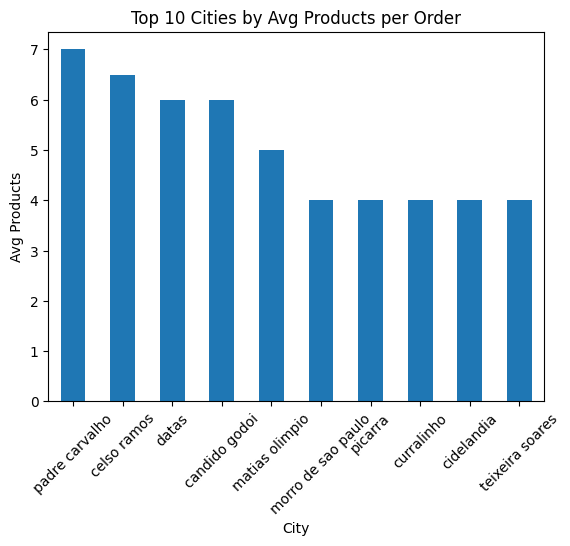

In [ ]:
#2Avg Products per order



items_per_order = order_items.groupby('order_id').size().reset_index(name='num_products')

cust_orders = orders[['order_id','customer_id']].merge(items_per_order, on='order_id')

cust_city = cust_orders.merge(customers[['customer_id','customer_city']], on='customer_id')

avg_products = cust_city.groupby('customer_city')['num_products'].mean()

top_cities = avg_products.sort_values(ascending=False).head(10)
print(avg_products.sort_values(ascending=False).head())
plt.figure()
top_cities.plot(kind='bar')
plt.title("Top 10 Cities by Avg Products per Order")
plt.xlabel("City")
plt.ylabel("Avg Products")
plt.xticks(rotation=45)
plt.show()

product category
HEALTH BEAUTY                  9.384664
Watches present                8.984461
bed table bath                 7.731735
sport leisure                  7.366843
computer accessories           6.799485
                                 ...   
flowers                        0.008276
House Comfort 2                0.005669
cds music dvds                 0.005443
Fashion Children's Clothing    0.004249
insurance and services         0.002112
Name: price, Length: 73, dtype: float64


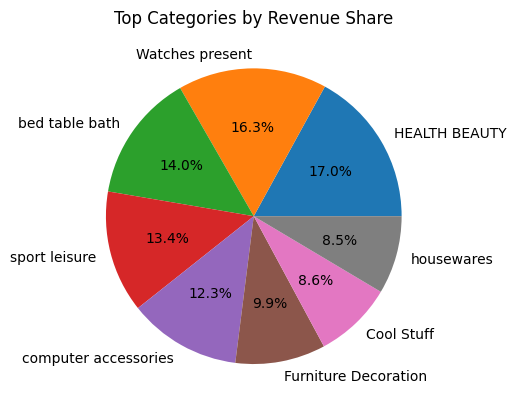

In [ ]:
#3. Percentage of revenue by category
df_cat = order_items.merge(products, on='product_id')

category_rev = df_cat.groupby('product category')['price'].sum()

top_categories = category_rev.sort_values(ascending=False).head(8)
print(percentage.sort_values(ascending=False))

plt.figure()
top_categories.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top Categories by Revenue Share")
plt.ylabel("")
plt.show()



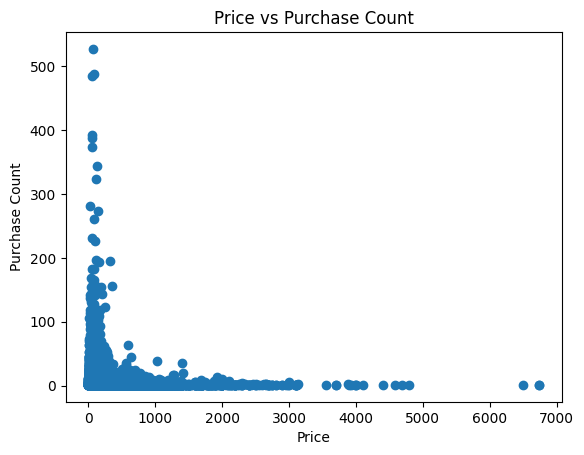

Correlation: -0.032139862680945416


In [ ]:
#4. Correlation
prod_counts = order_items.groupby('product_id').size()
prod_price = order_items.groupby('product_id')['price'].mean()

merged = pd.concat([prod_counts, prod_price], axis=1)
merged.columns = ['purchase_count','price']

plt.figure()
plt.scatter(merged['price'], merged['purchase_count'])
plt.title("Price vs Purchase Count")
plt.xlabel("Price")
plt.ylabel("Purchase Count")
plt.show()
print("Correlation:", correlation)

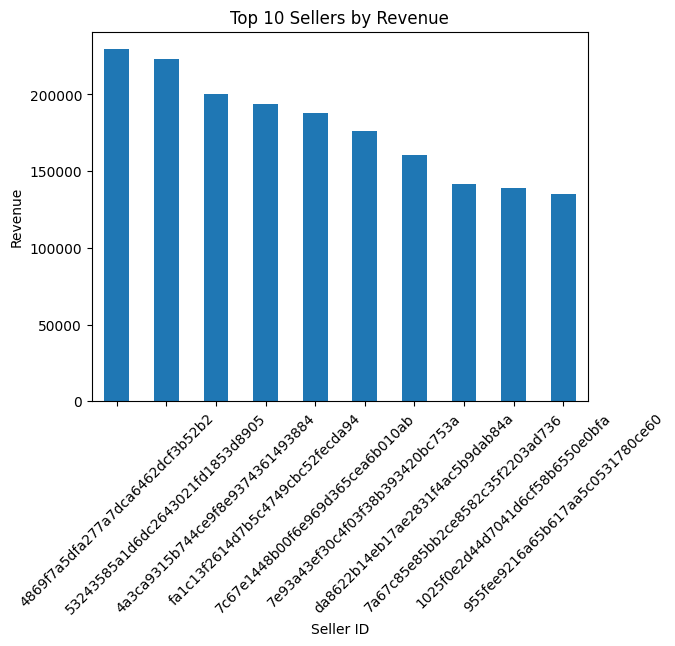

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
Name: price, dtype: float64


In [ ]:
#5 -- 5. Total revenue per seller + ranking
seller_revenue = order_items.groupby('seller_id')['price'].sum().sort_values(ascending=False)

top_sellers = seller_revenue.head(10)

plt.figure()
top_sellers.plot(kind='bar')
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()
print(seller_revenue.head())

Advance problems

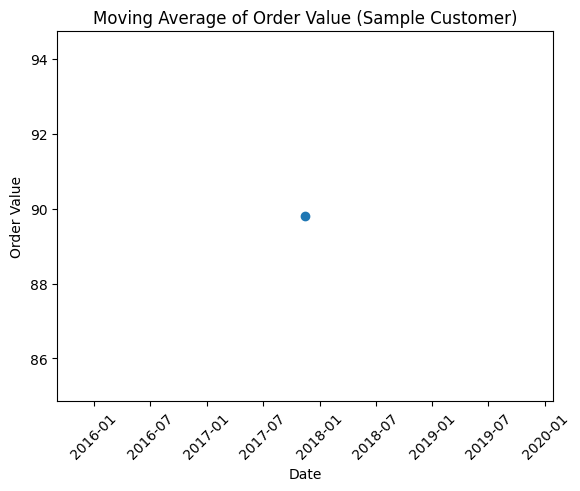

In [ ]:
#1

# Prepare data
order_value = order_items.groupby('order_id')['price'].sum().reset_index()
df_mv = orders.merge(order_value, on='order_id')

df_mv = df_mv.sort_values(['customer_id','order_purchase_timestamp'])

df_mv['moving_avg'] = df_mv.groupby('customer_id')['price']\
                          .transform(lambda x: x.rolling(3, min_periods=1).mean())

# Plot for one sample customer
sample_customer = df_mv['customer_id'].iloc[0]
sample_data = df_mv[df_mv['customer_id'] == sample_customer]

plt.figure()
plt.plot(sample_data['order_purchase_timestamp'], sample_data['price'], marker='o')
plt.plot(sample_data['order_purchase_timestamp'], sample_data['moving_avg'], linestyle='--')
plt.title("Moving Average of Order Value (Sample Customer)")
plt.xlabel("Date")
plt.ylabel("Order Value")
plt.xticks(rotation=45)
plt.show()

   year    month      price  cumulative_sales
0  2016  2016-09     267.36            267.36
1  2016  2016-10   49507.66          49775.02
2  2016  2016-12      10.90          49785.92
3  2017  2017-01  120312.87         120312.87
4  2017  2017-02  247303.02         367615.89


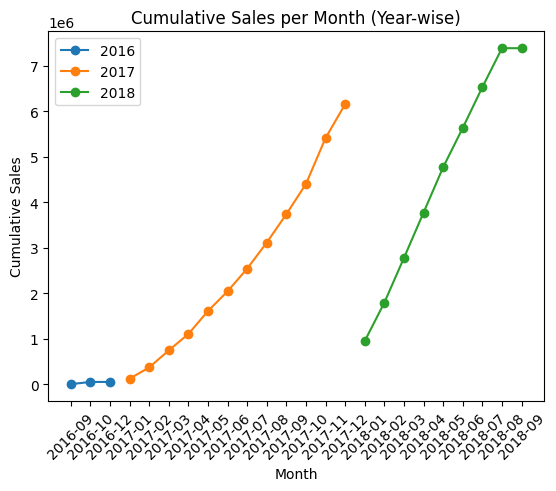

In [ ]:
#2
df_sales = orders.merge(order_items, on='order_id')

df_sales['year'] = df_sales['order_purchase_timestamp'].dt.year
df_sales['month'] = df_sales['order_purchase_timestamp'].dt.to_period('M')

monthly_sales = df_sales.groupby(['year','month'])['price'].sum().reset_index()

monthly_sales['cumulative_sales'] = monthly_sales.groupby('year')['price'].cumsum()

print(monthly_sales.head())

# Plot
plt.figure()
for year in monthly_sales['year'].unique():
    data = monthly_sales[monthly_sales['year'] == year]
    plt.plot(data['month'].astype(str), data['cumulative_sales'], marker='o', label=year)



plt.title("Cumulative Sales per Month (Year-wise)")
plt.xlabel("Month")
plt.ylabel("Cumulative Sales")
plt.xticks(rotation=45)
plt.legend()
plt.show()

   year       price    YoY_growth
0  2016    49785.92           NaN
1  2017  6155806.98  12264.554035
2  2018  7386050.80     19.985094


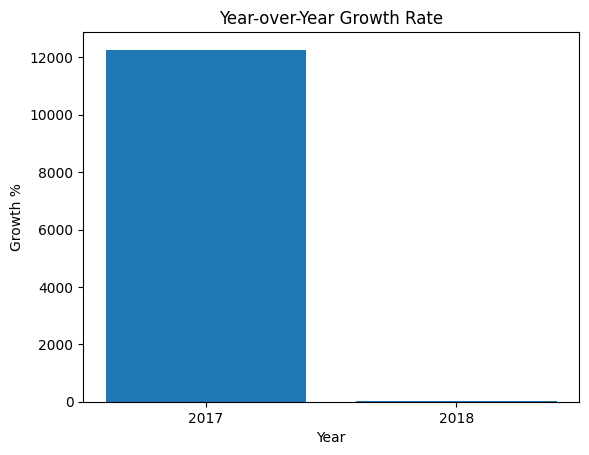

   year       price    YoY_growth
0  2016    49785.92           NaN
1  2017  6155806.98  12264.554035
2  2018  7386050.80     19.985094


In [ ]:
#3
yearly_sales = df_sales.groupby('year')['price'].sum().reset_index()
yearly_sales['YoY_growth'] = yearly_sales['price'].pct_change() * 100

print(yearly_sales)

plt.figure()
plt.bar(yearly_sales['year'].astype(str), yearly_sales['YoY_growth'])
plt.title("Year-over-Year Growth Rate")
plt.xlabel("Year")
plt.ylabel("Growth %")
plt.show()

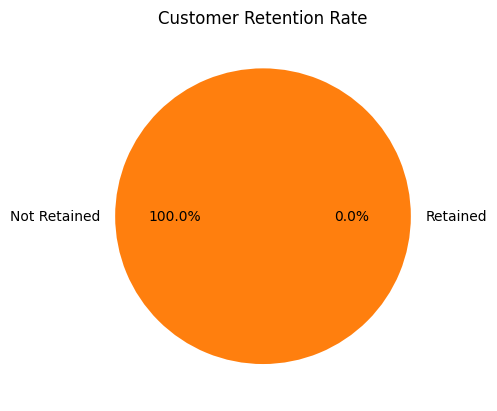

Retention %: 0.0


In [ ]:
#4

df_ret = orders.sort_values(['customer_id','order_purchase_timestamp'])

first_purchase = df_ret.groupby('customer_id')['order_purchase_timestamp'].min().reset_index()
first_purchase.columns = ['customer_id','first_date']

df_ret = df_ret.merge(first_purchase, on='customer_id')

df_ret['within_6_months'] = (
    (df_ret['order_purchase_timestamp'] > df_ret['first_date']) &
    (df_ret['order_purchase_timestamp'] <= df_ret['first_date'] + pd.DateOffset(months=6))
)

retained = df_ret[df_ret['within_6_months']]['customer_id'].nunique()
total = first_purchase['customer_id'].nunique()

labels = ['Retained','Not Retained']
values = [retained, total - retained]

plt.figure()
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Customer Retention Rate")
plt.show()

print("Retention %:", (retained/total)*100)

       year                       customer_id     price
213    2016  a9dc96b027d1252bbac0a9b72d837fc6   1399.00
37     2016  1d34ed25963d5aae4cf3d7f3a4cda173   1299.99
80     2016  4a06381959b6670756de02e07b83815f   1199.00
4156   2017  1617b1357756262bfa56ab541c47bc16  13440.00
35059  2017  c6e2731c5b391845f6800c97401a43a9   6735.00
11418  2017  3fd6777bbce08a352fddd04e4a7cc8f6   6499.00
94592  2018  ec5b2ba62e574342386871631fafd3fc   7160.00
96320  2018  f48d464a0baaea338cb25f816991ab1f   6729.00
92125  2018  e0a2412720e9ea4f26c1ac985f6a7358   4599.90


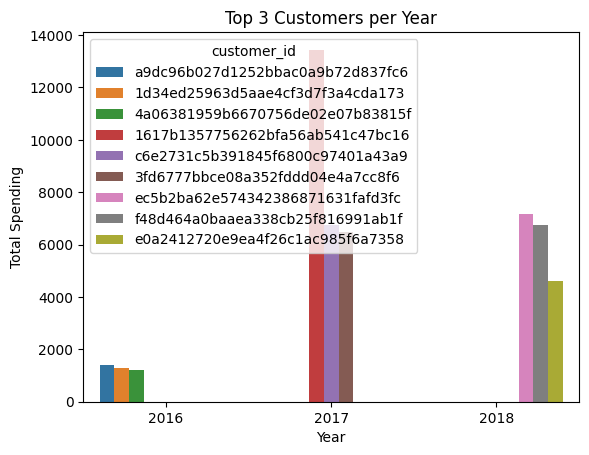

       year                       customer_id     price
213    2016  a9dc96b027d1252bbac0a9b72d837fc6   1399.00
37     2016  1d34ed25963d5aae4cf3d7f3a4cda173   1299.99
80     2016  4a06381959b6670756de02e07b83815f   1199.00
4156   2017  1617b1357756262bfa56ab541c47bc16  13440.00
35059  2017  c6e2731c5b391845f6800c97401a43a9   6735.00
11418  2017  3fd6777bbce08a352fddd04e4a7cc8f6   6499.00
94592  2018  ec5b2ba62e574342386871631fafd3fc   7160.00
96320  2018  f48d464a0baaea338cb25f816991ab1f   6729.00
92125  2018  e0a2412720e9ea4f26c1ac985f6a7358   4599.90


In [ ]:
df_top = orders.merge(order_items, on='order_id')

df_top['year'] = df_top['order_purchase_timestamp'].dt.year

customer_spend = df_top.groupby(['year','customer_id'])['price'].sum().reset_index()

top_customers = customer_spend.sort_values(['year','price'], ascending=[True,False])\
                             .groupby('year').head(3)

print(top_customers)
# Plot
plt.figure()
sns.barplot(data=top_customers, x='year', y='price', hue='customer_id')
plt.title("Top 3 Customers per Year")
plt.xlabel("Year")
plt.ylabel("Total Spending")
plt.show()

print(top_customers)